# What genes could promote stalled megakaryocyte maturation unique to the T21/GATA1s condition in "HPC - MK bias 1/2" cells

To test, consider:

The top MK lineage driver genes
- a. q-value < 0.1
- b. positively correlated with MK lineage.

Using the GLM results, differentially expressed in T21/GATA1s “HPC - MK bias 1/2” cells
- a. q-value < 0.01
- b. conditionT21:genotypeGATA1s interaction coefficient > 0 (this will help filter out genes that are downregulated in T21/GATA1s compared to T21/wtGATA1)

## Import packages & data

In [ ]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import anndata as ad
import cellrank as cr
from cellrank.kernels import CytoTRACEKernel
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats.mstats import mquantiles
from scipy.cluster.hierarchy import fcluster
import warnings
warnings.filterwarnings('ignore')

# cr.settings.verbosity = 2
# sc.settings.set_figure_params(frameon=False, dpi=100)
# scv.logging.print_version()
# scv.settings.verbosity = 3  # show errors(0), warnings(1), info(2), hints(3)
# scv.settings.presenter_view = True  # set max width size for presenter view
# scv.set_figure_params()  # for beautified visualization

/tmp/ipykernel_3989839/3908538346.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Load data

The dataset contains 3 time-points (days 7, 9, & 11) of iPSCs cell development for wtGATA and GATA1s genotype mutation samples

In [ ]:
# Load anndata file converted from Seurat integrated object
adata = scv.read("../seurat_objects/timecourse-d7911-renamed-pub-merged.h5ad")
adata

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'cell_type_colors', 'time_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

## Preprocess data

Basic preprocessing of the data before applying the CytoTRACE kernel

In [ ]:
# filter, normalize total counts and log-transform
sc.pp.filter_genes(adata, min_cells = 3)
scv.pp.normalize_per_cell(adata, enforce=True)
sc.pp.log1p(adata)

# hvg annotation
sc.pp.highly_variable_genes(adata, n_top_genes = 6000)
print(f"This detected {adata.var['highly_variable'].sum()} highly variable genes. ")
adata

Normalized count data: X, spliced, unspliced.
This detected 6000 highly variable genes. 


AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

CytoTRACE uses imputed gene expression to calculate the score of differentiation potential. Here, we use use scvelo.pp.moments() for imputation. We’re copying our X matrix into the layers because that’s where moments() expects to find counts for imputation

In [ ]:
adata.layers["spliced"] = adata.X
adata.layers["unspliced"] = adata.X
scv.pp.moments(adata, n_pcs=30, n_neighbors=50)

computing neighbors
    finished (0:01:45) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:10:18) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


## Compute the CytoTRACE score and transition matrix

In [ ]:
warnings.filterwarnings('ignore')
ctk = CytoTRACEKernel(adata).compute_cytotrace()
ctk.compute_transition_matrix(threshold_scheme="soft", nu=0.5)
adata.obs.columns

  0%|          | 0/148750 [00:00<?, ?cell/s]

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt',
       'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score',
       'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time',
       'sample_batch', 'batch', 'initial_size_unspliced',
       'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score',
       'ct_pseudotime', 'ct_num_exp_genes'],
      dtype='object')

## Computing terminal States

In [ ]:
## Initialize an estimator to compute initial and terminal states
g = cr.estimators.GPCCA(ctk)
print(g)

GPCCA[kernel=CytoTRACEKernel[n=148750], initial_states=None, terminal_states=None]


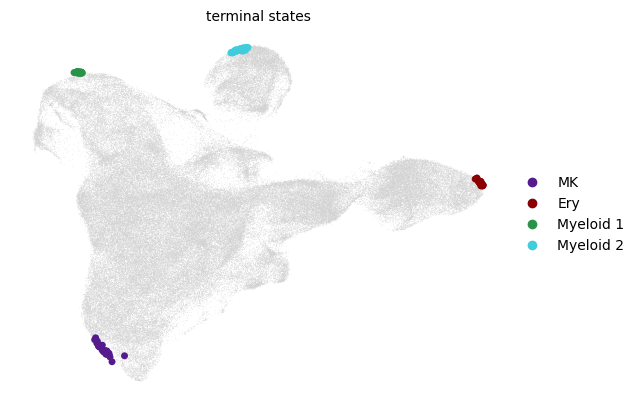

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'schur_vectors_fwd', 'macrostates_fwd_memberships', 'term_states_fwd_memberships'
    layer

In [ ]:
# Compute microstates based on the real Shur decomposition
warnings.filterwarnings('ignore')
g.compute_schur(n_components=20)
g.compute_macrostates(n_states=7, n_cells=30, cluster_key="cell_type")
g.set_terminal_states(states=["MK", "Ery", "Myeloid_1", "Myeloid_2"], allow_overlap=True)
g.plot_macrostates(which="terminal", basis="umap_integrated",  legend_loc="right", s=100, discrete=True)
adata

## Estimating fate probabilities and computering driver genes for all terminal trajectories

In [ ]:
warnings.filterwarnings('ignore')
g.compute_fate_probabilities(tol=1e-20)
driver_genes = g.compute_lineage_drivers()

  0%|          | 0/4 [00:00<?, ?/s]

[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


Add latent time from scVelo to the metadata (adata.obs) to use for pseudotemporalordering with CellRank's fate probabilities to visualize each gene's expression along specific trajectories (intial to termiates states along a lineage). CellRank's ct_pseudotime a bit more re-oreinting in order to obtain the correct expression cascades of sequential activation.

In [ ]:
latent_time = pd.read_csv("../results/timecourse/timecourse-d7911-renamed-latent-time.csv.gz")[["barcode", "latent_time"]]
latent_time
adata.obs = adata.obs.merge(latent_time, on='barcode', how='left')
adata

AnnData object with n_obs × n_vars = 148750 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'latent_time'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'schur_vectors_fwd', 'macrostates_fwd_memberships', 'term_states_fwd_members

## Ery lineage diver genes and  MAST "HPC - Ery bias" DEGs

In [ ]:
# lineage drivers
adata_hpc = adata[adata.obs["cell_type"]== "HPCs"]
adata_hpc

View of AnnData object with n_obs × n_vars = 13351 × 29918
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'latent_time'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'schur_vectors_fwd', 'macrostates_fwd_memberships', 'term_states_fwd_

In [ ]:
term_probs = pd.DataFrame(adata_hpc.obsm['term_states_fwd_memberships'],
                          columns=adata_hpc.obsm['term_states_fwd_memberships'].names,
                          index=adata_hpc.obs_names)
term_probs['MK'].quantile(np.arange(0,1,0.1))

0.0    0.000000
0.1    0.001991
0.2    0.003113
0.3    0.003960
0.4    0.005804
0.5    0.009236
0.6    0.012626
0.7    0.015766
0.8    0.022973
0.9    0.041969
Name: MK, dtype: float64

In [ ]:
thresh = term_probs['MK'].quantile(0.5)
prob_test = term_probs.apply(lambda x: x['MK'] > thresh, axis=1)
adata_mk_bc = term_probs.index[prob_test].values.tolist()
print(len(adata_mk_bc))
other_mk_bc = adata.obs_names[adata.obs['cell_type'].isin(['MK', 'HPC - MK bias 1', 'HPC - MK bias 2'])].tolist()
adata_mk_bc.extend(other_mk_bc)
print(len(other_mk_bc))

6675
75924


In [ ]:
adata.varm['terminal_lineage_drivers']

,MK_corr,MK_pval,MK_qval,MK_ci_low,MK_ci_high,Ery_corr,Ery_pval,Ery_qval,Ery_ci_low,Ery_ci_high,Myeloid_1_corr,Myeloid_1_pval,Myeloid_1_qval,Myeloid_1_ci_low,Myeloid_1_ci_high,Myeloid_2_corr,Myeloid_2_pval,Myeloid_2_qval,Myeloid_2_ci_low,Myeloid_2_ci_high
AL627309.1,6.794094e-03,8.783480e-03,1.639021e-02,0.001712,0.011876,-0.008097,1.790353e-03,3.915194e-03,-0.013178,-0.003015,-0.000534,8.368352e-01,8.832766e-01,-0.005616,0.004548,-0.006602,1.088267e-02,2.753616e-02,-0.011684,-0.001521
AL627309.5,6.317049e-03,1.483529e-02,2.680531e-02,0.001235,0.011399,-0.007621,3.287699e-03,6.977468e-03,-0.012703,-0.002540,-0.000411,8.741678e-01,9.104735e-01,-0.005492,0.004671,-0.006242,1.606064e-02,3.934994e-02,-0.011324,-0.001160
LINC01409,7.596559e-04,7.695358e-01,8.214862e-01,-0.004322,0.005841,-0.020508,2.563573e-15,1.038691e-14,-0.025587,-0.015428,0.002372,3.602214e-01,4.834734e-01,-0.002710,0.007454,0.016767,9.990175e-11,5.529806e-10,0.011686,0.021847
LINC01128,1.347944e-02,2.003305e-07,5.327073e-07,0.008398,0.018560,0.020987,5.710064e-16,2.365790e-15,0.015907,0.026066,-0.018632,6.634801e-13,2.391566e-12,-0.023712,-0.013551,-0.013675,1.332246e-07,6.039112e-07,-0.018755,-0.008593
LINC00115,-3.195985e-04,9.018997e-01,9.260428e-01,-0.005401,0.004762,-0.003805,1.421931e-01,2.203644e-01,-0.008887,0.001276,0.002687,3.000064e-01,4.177997e-01,-0.002395,0.007769,-0.001320,6.107187e-01,7.395266e-01,-0.006402,0.003762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AP001610.3,-2.202867e-02,1.939936e-17,7.399161e-17,-0.027107,-0.016949,-0.002362,3.623149e-01,4.769541e-01,-0.007444,0.002720,0.025045,4.402079e-22,2.030549e-21,0.019966,0.030123,-0.002557,3.239561e-01,4.898967e-01,-0.007639,0.002524
AP001056.1,-1.848124e-02,1.013886e-12,3.349910e-12,-0.023561,-0.013401,-0.001945,4.531604e-01,5.656800e-01,-0.007027,0.003137,0.020984,5.763279e-16,2.277450e-15,0.015904,0.026063,-0.002120,4.136105e-01,5.806578e-01,-0.007202,0.002962
AIRE,-8.317252e-03,1.337315e-03,2.726596e-03,-0.013399,-0.003236,-0.001493,5.647988e-01,6.636003e-01,-0.006575,0.003589,0.005365,3.853951e-02,6.902854e-02,0.000283,0.010446,0.010009,1.132024e-04,3.890178e-04,0.004927,0.015090
LRRC3-DT,-1.387967e-02,8.630848e-08,2.341474e-07,-0.018960,-0.008798,-0.001825,4.815536e-01,5.922763e-01,-0.006907,0.003257,0.016094,5.372511e-10,1.736922e-09,0.011014,0.021175,-0.001994,4.419391e-01,6.060627e-01,-0.007075,0.003088


In [ ]:
# Get driver genes positively correlated with MK lineage and negatively correlated with both the myeloid and MK lineages
# making sure results are specific to erythroid
driver_degs = adata.varm['terminal_lineage_drivers']
# driver_degs = driver_degs.loc[(driver_degs['MK_qval'] < 0.1) & (driver_degs['MK_corr'] > 0) & (driver_degs['Ery_corr'] < 0) & (driver_degs['Myeloid_1_corr'] < 0) & (driver_degs['Myeloid_2_corr'] < 0)].index.tolist()
driver_degs = driver_degs.loc[(driver_degs['MK_qval'] < 0.05) & (driver_degs['MK_corr'] > 0)].index.tolist()
print(len(driver_degs))

10206


In [ ]:
# Get significant MAST DEGs keeping only upregulated in T21/GATA1s compared to T21/wtGATA1
mast_res = pd.read_csv("../results/timecourse/timecourse-d7911-renamed-mast-zlmCond-HPC-MK-bias-DEGs.tsv.gz", sep = "\t", index_col=0)
mast_degs = mast_res[(mast_res['fdr'] < 0.05) & (mast_res['conditionT21:genotypeGATA1s']>0)].index.tolist()
print(len(mast_degs))

1244


In [ ]:
# subset to genes of interest (all drivers intersected with MAST result)
driver_mast_degs = set(driver_degs).intersection(mast_degs)
with open("../results/timecourse/timecourse-d7911-renamed-stalled-megakaroid-maturation-DEGs.txt", "w") as outfile:
    outfile.write("\n".join(driver_mast_degs))
len(driver_mast_degs)

671

In [ ]:
pdata = adata[adata_mk_bc, adata.var_names.isin(driver_mast_degs)].copy()
pt_bins = mquantiles(pdata.obs.ct_pseudotime, prob=np.arange(0,1,0.1))
pt_bins = np.concatenate([[0],pt_bins,[1]])
pt_bins

array([0.        , 0.01397723, 0.28834567, 0.30807837, 0.32227699,
       0.33468849, 0.34665984, 0.35918784, 0.37356192, 0.3938465 ,
       0.44065356, 1.        ])

In [ ]:
pdata.obs['pt_bins'] = np.digitize(pdata.obs.ct_pseudotime.to_numpy(), pt_bins)
pdata

AnnData object with n_obs × n_vars = 82599 × 671
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score', 'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time', 'sample_batch', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score', 'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'latent_time', 'pt_bins'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'n_cells', 'gene_count_corr', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ct_gene_corr', 'ct_correlates'
    uns: 'cell_type_colors', 'time_colors', 'log1p', 'hvg', 'neighbors', 'ct_params', 'schur_matrix_fwd', 'eigendecomposition_fwd', 'macrostates_fwd_colors', 'coarse_fwd', 'term_states_fwd_colors'
    obsm: 'X_pca', 'X_umap_integrated', 'X_umap_merged', 'schur_vectors_fwd', 'macrostates_fwd_memberships', 'term_states_fwd

In [ ]:
pdata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt',
       'seurat_clusters', 'integrated_snn_res.0.4', 'cell_type', 'S.Score',
       'G2M.Score', 'Phase', 'barcode', 'condition', 'genotype', 'time',
       'sample_batch', 'batch', 'initial_size_unspliced',
       'initial_size_spliced', 'initial_size', 'n_counts', 'ct_score',
       'ct_pseudotime', 'ct_num_exp_genes', 'macrostates_fwd',
       'term_states_fwd', 'term_states_fwd_probs', 'latent_time', 'pt_bins'],
      dtype='object')

In [ ]:
pdata.obs['sample'] = pdata.obs['condition'].str.cat(pdata.obs['genotype'], sep="-")
hdata = pd.DataFrame(pdata.X.toarray(), columns=pdata.var_names, index=pdata.obs_names)
hdata['bins'] = pdata.obs['pt_bins']
hdata['sample'] = pdata.obs['sample']
hdata = hdata.groupby(['sample','bins']).agg(np.mean)
#hdata = hdata.sort_index(level=[0],ascending=[False])
#hdata = hdata.drop(12, level = 1)
hdata

SLC35E2B    PRXL2B     SMIM1     PHF13    VPS13D  \
sample          bins                                                     
Euploid-GATA1s  2     0.092232  0.054986  0.377423  0.083346  0.418688   
                3     0.075416  0.057799  0.404715  0.075799  0.364069   
                4     0.081140  0.044262  0.426497  0.067065  0.344700   
                5     0.078425  0.050320  0.445784  0.067001  0.344389   
                6     0.072721  0.055852  0.435460  0.059340  0.297046   
                7     0.069031  0.053463  0.436929  0.050727  0.319232   
                8     0.066788  0.041439  0.422006  0.058205  0.271771   
                9     0.068573  0.043115  0.435905  0.056321  0.279687   
                10    0.054189  0.032246  0.422380  0.051452  0.288275   
                11    0.049489  0.027039  0.309737  0.050438  0.287332   
Euploid-wtGATA1 2     0.106339  0.075748  0.784623  0.087829  0.653365   
                3     0.084881  0.067052  0.667595  0.088020  0.487192   
                4     0.103176  0.059691  0.658827  0.078785  0.442186   
                5     0.079625  0.053614  0.627309  0.066227  0.398372   
                6     0.059362  0.051570  0.613348  0.056549  0.382982   
                7     0.071400  0.035958  0.596504  0.056527  0.361825   
                8     0.074458  0.047297  0.591296  0.058962  0.332010   
                9     0.051478  0.043848  0.556951  0.061817  0.315480   
                10    0.054869  0.032780  0.509137  0.048004  0.269670   
                11    0.031756  0.017699  0.456086  0.035498  0.149613   
T21-GATA1s      2     0.062325  0.048673  0.357573  0.050862  0.381011   
                3     0.053400  0.063848  0.392831  0.063598  0.346403   
                4     0.052075  0.049302  0.364376  0.061328  0.312566   
                5     0.048232  0.044537  0.364774  0.070850  0.299460   
                6     0.055777  0.056760  0.365703  0.063072  0.258278   
                7     0.056189  0.050395  0.365128  0.058191  0.245991   
                8     0.062885  0.037212  0.346654  0.055187  0.241820   
                9     0.055103  0.042791  0.359303  0.060486  0.252298   
                10    0.065322  0.035955  0.339543  0.053502  0.225400   
                11    0.039398  0.039290  0.255551  0.043549  0.221139   
T21-wtGATA1     2     0.063190  0.044535  0.459316  0.072210  0.395295   
                3     0.060047  0.047430  0.516856  0.072567  0.356872   
                4     0.061082  0.045282  0.501573  0.061050  0.351374   
                5     0.060591  0.051498  0.528991  0.068627  0.338753   
                6     0.058843  0.042604  0.528206  0.056238  0.335453   
                7     0.058492  0.045922  0.513637  0.058934  0.323179   
                8     0.055156  0.035693  0.529057  0.066140  0.313987   
                9     0.058104  0.039603  0.519942  0.067998  0.320342   
                10    0.057621  0.040537  0.541828  0.074101  0.327324   
                11    0.034691  0.033714  0.548675  0.049402  0.290908   

                        UQCRHL     MFAP2     OTUD3    HP1BP3   PHACTR4  ...  \
sample          bins                                                    ...   
Euploid-GATA1s  2     0.035603  0.022701  0.092440  0.933920  0.705354  ...   
                3     0.033419  0.012707  0.076456  0.811625  0.608762  ...   
                4     0.045926  0.015406  0.074787  0.739073  0.571065  ...   
                5     0.030890  0.015319  0.063169  0.726020  0.533070  ...   
                6     0.029397  0.012199  0.048605  0.651492  0.471269  ...   
                7     0.024871  0.012308  0.051468  0.649372  0.463271  ...   
                8     0.029202  0.009706  0.041126  0.621802  0.432395  ...   
                9     0.036134  0.012502  0.048305  0.607620  0.429251  ...   
                10    0.027485  0.012505  0.048308  0.566232  0.377670  ...   
                11    0.020563  0.012535  0.

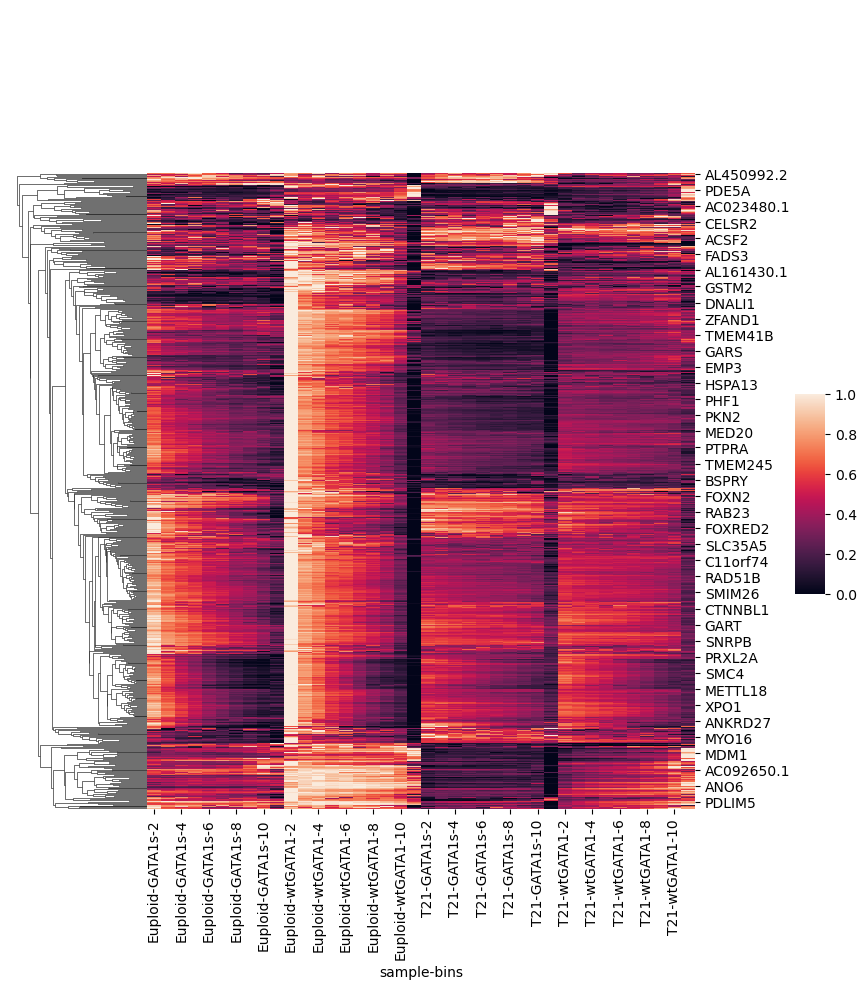

In [ ]:
p = sns.clustermap(hdata.T, col_cluster=False, standard_scale=0)
p.fig.subplots_adjust(right=0.7)
p.ax_cbar.set_position((0.8, .4, .03, .2))
plt.savefig("figures/timecourse-d7911-renamed-MK-DEGs-heatmap.png")